In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project paths
PROJECT_ROOT = Path(r"C:\Users\DELL\OneDrive\Desktop\capstone project")
DATA_PATH = PROJECT_ROOT / "data" / "processed"

# Load required datasets
nav = pd.read_csv(DATA_PATH / "02_nav_history_cleaned.csv")
fund_master = pd.read_csv(DATA_PATH / "01_fund_master_cleaned.csv")
transactions = pd.read_csv(DATA_PATH / "08_investor_transactions_cleaned.csv")
holdings = pd.read_csv(DATA_PATH / "09_portfolio_holdings_cleaned.csv")
performance = pd.read_csv(DATA_PATH / "07_scheme_performance_cleaned.csv")

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

print("NAV:", nav.shape)
print("Fund Master:", fund_master.shape)
print("Transactions:", transactions.shape)
print("Holdings:", holdings.shape)
print("Performance:", performance.shape)

NAV: (46000, 3)
Fund Master: (40, 15)
Transactions: (32778, 13)
Holdings: (322, 8)
Performance: (40, 19)


In [2]:
# Historical VaR (95%) and CVaR for all 40 schemes

# Sort NAV data
nav = nav.sort_values(["amfi_code", "date"])

# Calculate daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

# Calculate VaR and CVaR for each fund
var_cvar_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    # Historical VaR at 95% confidence = 5th percentile
    var_95 = np.percentile(returns, 5)

    # CVaR = mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()

    var_cvar_results.append({
        "amfi_code": amfi_code,
        "VaR_95_pct": var_95 * 100,
        "CVaR_95_pct": cvar_95 * 100
    })

var_cvar_report = pd.DataFrame(var_cvar_results)

# Add fund information
var_cvar_report = var_cvar_report.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "risk_category"]],
    on="amfi_code",
    how="left"
)

# Arrange columns
var_cvar_report = var_cvar_report[
    ["amfi_code", "scheme_name", "fund_house", "risk_category",
     "VaR_95_pct", "CVaR_95_pct"]
]

# Sort by VaR
var_cvar_report = var_cvar_report.sort_values("VaR_95_pct")

# Display results
display(var_cvar_report)

print("Number of schemes:", len(var_cvar_report))

,amfi_code,scheme_name,fund_house,risk_category,VaR_95_pct,CVaR_95_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Very High,-2.685944,-3.238412
17,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Very High,-2.618842,-3.166729
4,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Very High,-2.602125,-3.245906
11,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Very High,-2.543811,-3.230407
21,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Very High,-2.450705,-3.059526
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Very High,-2.348307,-3.103625
7,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,High,-1.922028,-2.325086
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,High,-1.903354,-2.345576
25,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,-1.889179,-2.434207
16,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,High,-1.848028,-2.426006


Number of schemes: 40


In [3]:
# Save VaR and CVaR report
var_cvar_report.to_csv(
    PROJECT_ROOT / "var_cvar_report.csv",
    index=False
)

print("Saved: var_cvar_report.csv")

Saved: var_cvar_report.csv


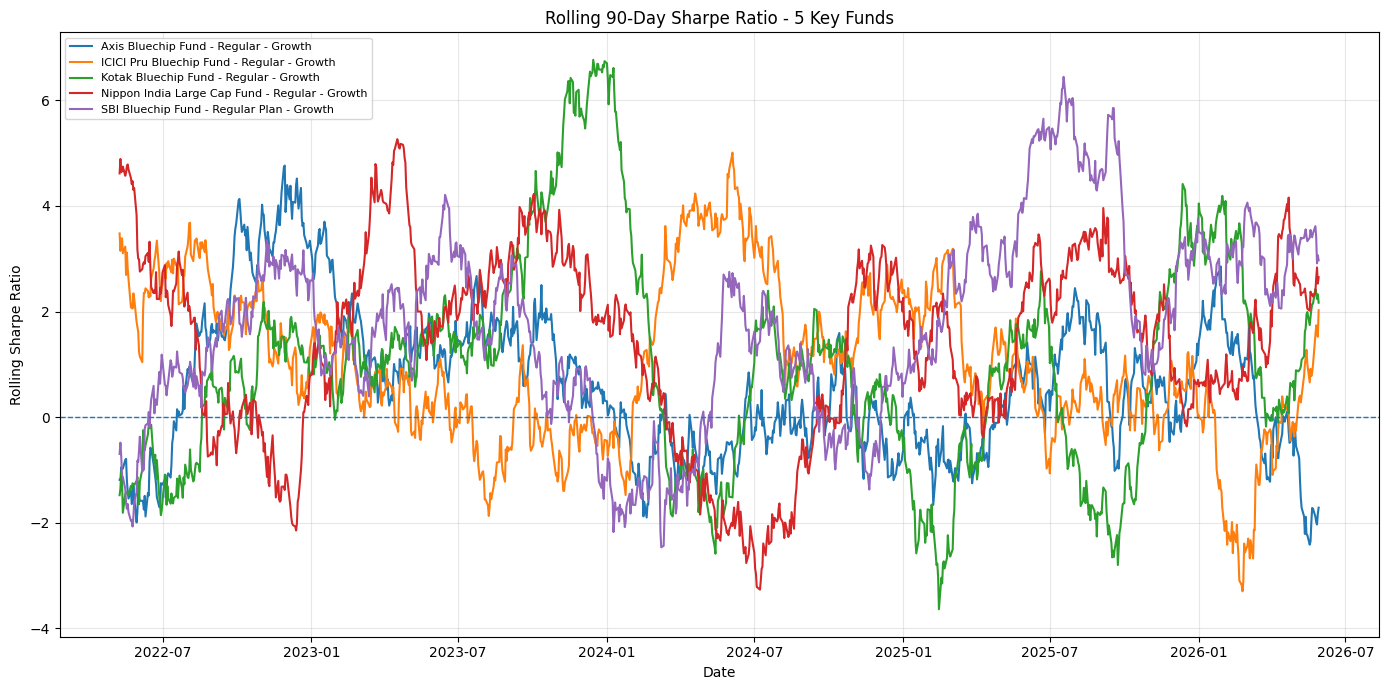

Saved: rolling_sharpe_chart.png


In [4]:
# Rolling 90-day Sharpe Ratio for 5 key funds

key_funds = [119551, 120503, 118632, 119092, 120841]

rolling_data = nav[nav["amfi_code"].isin(key_funds)].copy()

rolling_data["rolling_sharpe_90d"] = (
    rolling_data.groupby("amfi_code")["daily_return"]
    .transform(
        lambda x: (
            x.rolling(90).mean() /
            x.rolling(90).std()
        ) * np.sqrt(252)
    )
)

# Add scheme names
rolling_data = rolling_data.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Plot
plt.figure(figsize=(14, 7))

for scheme_name, group in rolling_data.groupby("scheme_name"):
    plt.plot(
        group["date"],
        group["rolling_sharpe_90d"],
        label=scheme_name
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Rolling 90-Day Sharpe Ratio - 5 Key Funds")
plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()

# Required deliverable
plt.savefig(
    PROJECT_ROOT / "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: rolling_sharpe_chart.png")

In [5]:
# Investor Cohort Analysis

# Find each investor's first transaction year
first_transaction = (
    transactions.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction["cohort_year"] = (
    first_transaction["transaction_date"].dt.year
)

# Add cohort year to transactions
transactions_cohort = transactions.merge(
    first_transaction[["investor_id", "cohort_year"]],
    on="investor_id",
    how="left"
)

# Average SIP amount by cohort
sip_cohort = (
    transactions_cohort[
        transactions_cohort["transaction_type"] == "SIP"
    ]
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount_inr")
)

# Total invested by cohort
total_invested = (
    transactions_cohort[
        transactions_cohort["transaction_type"].isin(["SIP", "Lumpsum"])
    ]
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index(name="total_invested_inr")
)

# Top fund preference by cohort
fund_preference = (
    transactions_cohort[
        transactions_cohort["transaction_type"] == "SIP"
    ]
    .groupby(["cohort_year", "amfi_code"])
    .size()
    .reset_index(name="sip_transactions")
)

top_funds = (
    fund_preference
    .sort_values(
        ["cohort_year", "sip_transactions"],
        ascending=[True, False]
    )
    .groupby("cohort_year")
    .first()
    .reset_index()
)

# Add scheme names
top_funds = top_funds.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top_funds = top_funds[
    ["cohort_year", "scheme_name", "sip_transactions"]
]

# Combine cohort results
cohort_analysis = sip_cohort.merge(
    total_invested,
    on="cohort_year",
    how="outer"
).merge(
    top_funds,
    on="cohort_year",
    how="left"
)

# Display result
display(cohort_analysis)

,cohort_year,avg_sip_amount_inr,total_invested_inr,scheme_name,sip_transactions
0,2024,10996.885825,2258062304,ICICI Pru Bluechip Fund - Direct - Growth,536
1,2025,13505.209581,18992635,SBI Small Cap Fund - Direct Plan - Growth,8


In [6]:
# SIP Continuity Analysis

# Keep only SIP transactions
sip_transactions = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

# Sort transactions by investor and date
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

# Calculate gap in days between consecutive SIP transactions
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

# Keep investors with 6 or more SIP transactions
sip_counts = (
    sip_transactions.groupby("investor_id")
    .size()
    .reset_index(name="sip_transaction_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_transaction_count"] >= 6
]["investor_id"]

continuity = sip_transactions[
    sip_transactions["investor_id"].isin(eligible_investors)
].copy()

# Average gap between SIP transactions
continuity_report = (
    continuity.groupby("investor_id")
    .agg(
        sip_transaction_count=("gap_days", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

# Add 1 to transaction count because diff() excludes first transaction
continuity_report["sip_transaction_count"] += 1

# Flag investors with average gap > 35 days
continuity_report["continuity_status"] = np.where(
    continuity_report["avg_gap_days"] > 35,
    "at-risk",
    "active"
)

# Display result
display(continuity_report)

print("Eligible investors:", len(continuity_report))
print(
    "At-risk investors:",
    (continuity_report["continuity_status"] == "at-risk").sum()
)

,investor_id,sip_transaction_count,avg_gap_days,continuity_status
0,INV000004,6,85.400000,at-risk
1,INV000008,6,70.400000,at-risk
2,INV000010,6,64.800000,at-risk
3,INV000011,7,40.166667,at-risk
4,INV000012,8,57.000000,at-risk
...,...,...,...,...
1357,INV004984,7,75.333333,at-risk
1358,INV004986,7,81.333333,at-risk
1359,INV004992,7,81.500000,at-risk
1360,INV004996,10,46.333333,at-risk


Eligible investors: 1362
At-risk investors: 1332


In [7]:
# Sector HHI Concentration Analysis

# Calculate sector weight for each fund
sector_weights = (
    holdings.groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

# Calculate HHI = sum of squared sector weights
sector_hhi = (
    sector_weights.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: np.sum((x / 100) ** 2))
    .reset_index(name="sector_hhi")
)

# Add fund information
sector_hhi = sector_hhi.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

# Keep equity funds only
sector_hhi = sector_hhi[
    sector_hhi["category"].str.contains("Equity", case=False, na=False)
].copy()

# Sort by HHI
sector_hhi = sector_hhi.sort_values(
    "sector_hhi",
    ascending=False
)

# Display results
display(sector_hhi)

print("Equity funds analysed:", len(sector_hhi))

,amfi_code,sector_hhi,scheme_name,fund_house,category
11,119092,0.296769,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
30,148569,0.254992,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity
27,125498,0.253155,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity
6,102887,0.251383,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,Equity
32,149323,0.241077,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity
21,120505,0.238695,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
10,118635,0.237497,Nippon India ETF Nifty 50 BeES,Nippon India MF,Equity
18,119599,0.232361,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
22,120506,0.231464,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity
1,100033,0.227647,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity


Equity funds analysed: 34


## Advanced Analytics — Key Insights

1. **VaR and CVaR:** The Historical VaR and CVaR analysis provides a downside-risk view for all 40 schemes. Funds with more negative VaR and CVaR values experience larger potential daily losses at the 95% confidence level.

2. **Rolling Sharpe:** The 90-day rolling Sharpe analysis shows how risk-adjusted performance changes over time for the five selected funds, rather than relying only on a single full-period Sharpe ratio.

3. **Investor Cohorts:** Investors were grouped according to their first transaction year. The 2024 cohort recorded an average SIP amount of ₹10,996.89, while the 2025 cohort recorded ₹13,505.21.

4. **SIP Continuity:** Among investors with at least six SIP transactions, 1,362 investors qualified for continuity analysis. Of these, 1,332 were classified as **at-risk** because their average SIP gap exceeded 35 days.

5. **Sector Concentration:** Sector HHI analysis covered 34 equity funds. HHI values varied across funds, indicating differences in the concentration of sector exposure within equity portfolios.